# PCBert-Kla Research Workbook

This notebook documents and runs the cleaned PCBert-Kla replication, the proposed token-gated architecture, and the protein language model backbone comparison experiments.


## 1. Notebook Usage

Run this notebook from inside:

`experiment/pcbert_kla_clean/`

In Google Colab, after cloning the repository, use:

```python
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
```

Heavy training cells are controlled by boolean flags such as `RUN_PROTBERT_TOKEN_GATED`. Keep them set to `False` until you intentionally want to run that experiment.


In [1]:
!git clone https://github.com/kaleabnega/Lysine-Lactylation-Sites-Prediction.git
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean

Cloning into 'Lysine-Lactylation-Sites-Prediction'...
remote: Enumerating objects: 285, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 285 (delta 110), reused 246 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (285/285), 4.25 MiB | 20.07 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean


In [2]:

from pathlib import Path
import json
import os
import shlex
import subprocess
import sys

PROJECT_DIR = Path.cwd()
print("Current directory:", PROJECT_DIR)

expected = PROJECT_DIR / "scripts" / "run_replication.py"
if not expected.exists():
    raise RuntimeError(
        "This notebook should be run from experiment/pcbert_kla_clean. "
        f"Could not find {expected}."
    )

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project check passed.")

Current directory: /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
Project check passed.


## 2. Dependency Setup

On Colab, set `INSTALL_DEPENDENCIES = True` once per fresh runtime. If dependencies are already installed, leave it as `False`.


In [3]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        "requirements.txt",
    ])
else:
    print("Skipping dependency installation. Set INSTALL_DEPENDENCIES = True if needed.")

## 3. Helper Functions for Reproducible Commands

The notebook uses the same command-line runner used in the project README. Training cells can either print the command without running it, or execute the command, capture its terminal output, parse the final JSON metrics, and add those metrics to a generated results table.


In [4]:
try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
    print("pandas is not installed. Set INSTALL_DEPENDENCIES = True and rerun the dependency cell.")

NOTEBOOK_METRICS_DIR = PROJECT_DIR / "outputs" / "notebook_metrics"
NOTEBOOK_METRICS_DIR.mkdir(parents=True, exist_ok=True)

experiment_records = []
metric_cols = ["ACC", "AUC", "AUPRC", "F1", "MCC", "Pre", "Rec", "SP"]


def runner_args(*args: str) -> list[str]:
    return ["python", "scripts/run_replication.py", *args]


def command_text(command: list[str]) -> str:
    return " ".join(shlex.quote(part) for part in command)


def run_command(command: list[str], run: bool = True) -> None:
    print("$", command_text(command))
    if run:
        subprocess.run(command, check=True)


def extract_json_after_marker(output: str, marker: str) -> dict:
    marker_index = output.rfind(marker)
    if marker_index == -1:
        raise ValueError(f"Could not find marker in command output: {marker!r}")

    json_start = output.find("{", marker_index)
    if json_start == -1:
        raise ValueError(f"Could not find JSON object after marker: {marker!r}")

    decoder = json.JSONDecoder()
    parsed, _ = decoder.raw_decode(output[json_start:])
    return parsed


def safe_result_name(label: str) -> str:
    safe = "".join(ch.lower() if ch.isalnum() else "_" for ch in label).strip("_")
    while "__" in safe:
        safe = safe.replace("__", "_")
    return safe or "experiment"


def run_experiment(
    label: str,
    setting: str,
    command: list[str],
    run: bool,
    marker: str = "Independent test:",
) -> dict | None:
    print("$", command_text(command))
    if not run:
        print("Skipped. Set the corresponding RUN_* flag to True to execute this experiment.")
        return None

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    output_lines = []
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        output_lines.append(line)
    return_code = process.wait()
    output = "".join(output_lines)
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command, output=output)

    metrics = extract_json_after_marker(output, marker)
    record = {
        "Model": label,
        "Setting": setting,
        "Result marker": marker.rstrip(":"),
        **metrics,
        "Command": command_text(command),
    }
    experiment_records.append(record)

    output_path = NOTEBOOK_METRICS_DIR / f"{safe_result_name(label)}.json"
    output_path.write_text(json.dumps(record, indent=2, sort_keys=True))
    print(f"Saved parsed metrics to {output_path.relative_to(PROJECT_DIR)}")
    return record


def require_pandas():
    if pd is None:
        raise ModuleNotFoundError(
            "pandas is required for result tables. "
            "Set INSTALL_DEPENDENCIES = True and rerun the dependency cell."
        )


def load_saved_notebook_metrics():
    require_pandas()
    records = []
    for path in sorted(NOTEBOOK_METRICS_DIR.glob("*.json")):
        records.append(json.loads(path.read_text()))
    return pd.DataFrame(records)


## 4. Dataset Audit

This confirms that the original PCBert-Kla train/test files and physicochemical feature files are being used. It also prints the train/test overlap audit. The overlap is part of the original benchmark split; it is not introduced by this work.


In [5]:
run_command(runner_args("--run", "data-check"), run=True)

$ python scripts/run_replication.py --run data-check


In [6]:
!pwd
!ls
!python scripts/run_replication.py --run data-check

/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
main.ipynb  outputs  README.md	requirements.txt  scripts  src
{
  "test": {
    "class_counts": {
      "0": 177,
      "1": 177
    },
    "duplicate_sequence_rows": 5,
    "feature_dim": 27,
    "records": 354,
    "unique_sequences": 349
  },
  "train": {
    "class_counts": {
      "0": 1767,
      "1": 1720
    },
    "duplicate_sequence_rows": 1648,
    "feature_dim": 27,
    "records": 3487,
    "unique_sequences": 1839
  },
  "train_test_overlap": {
    "different_label_test_rows": 4,
    "overlap_test_rows": 255,
    "same_label_test_rows": 251,
    "unique_overlap_sequences": 251
  }
}


## 5. Model Architecture Summary

The proposed method is the token-gated architecture. It keeps the same 51-amino-acid lysine-centered windows and 27 physicochemical features as PCBert-Kla, but changes the downstream neural framework.

Main components:

- protein language model token embeddings from ProtBert, ESM-2, ProtT5, or Ankh,
- central-lysine-guided token attention pooling,
- a separate physicochemical feature projection branch,
- gated fusion between sequence and physicochemical representations,
- residual classifier for final Kla probability prediction.


## 6. Experiment Execution Policy

Metric values are not hardcoded in this notebook. Each table below is generated from commands that are executed in the notebook. The commands are disabled by default to avoid accidental long Colab runs; set the relevant `RUN_*` flag to `True`, run the cell, and the notebook will parse the generated terminal output into `experiment_records`.


In [7]:
print("Metric records currently stored in memory:", len(experiment_records))
print("Parsed metric JSON files will be written to:", NOTEBOOK_METRICS_DIR.relative_to(PROJECT_DIR))


Metric records currently stored in memory: 0
Parsed metric JSON files will be written to: outputs/notebook_metrics


## 7. Paper Baseline Reference

For strict reproducibility, this notebook reads the paper-reported PCBert-Kla independent-test metrics from `outputs/paper_reported_metrics.json` instead of hardcoding them inside the notebook cells. The generated difference table compares newly executed notebook results against that reference file.


In [8]:
paper_metrics_path = PROJECT_DIR / "outputs" / "paper_reported_metrics.json"
if paper_metrics_path.exists():
    paper_metrics = json.loads(paper_metrics_path.read_text())
    print("Loaded paper metrics from", paper_metrics_path.relative_to(PROJECT_DIR))
    if pd is not None:
        display(pd.DataFrame([{ "Model": "Paper PCBert-Kla", **paper_metrics }]))
    else:
        print(paper_metrics)
else:
    paper_metrics = None
    print("No paper metrics JSON found. Difference-from-paper table will be skipped until this file exists.")


Loaded paper metrics from outputs/paper_reported_metrics.json


,Model,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP,source
0,Paper PCBert-Kla,0.9497,0.9646,0.9523,0.9505,0.8999,0.9364,0.965,0.9345,PCBert-Kla paper reported independent-test met...


## 8. Command Overview

The following cells define and optionally run the baseline, proposed token-gated model, backbone comparison models, and ensemble model. Results are collected only from executed cells.


In [9]:
print("Available result metrics:", ", ".join(metric_cols))


Available result metrics: ACC, AUC, AUPRC, F1, MCC, Pre, Rec, SP


## 9. Baseline Replication Commands

These cells reproduce the original-style baseline. They are heavy training runs, so they are disabled by default.


In [10]:
RUN_BASELINE_INDEPENDENT = False

baseline_independent_cmd = runner_args(
    "--run", "independent",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
)

run_experiment(
    label="Baseline replication",
    setting="Original PCBert-Kla-style architecture, SGD",
    command=baseline_independent_cmd,
    run=RUN_BASELINE_INDEPENDENT,
    marker="Independent test:",
)


$ python scripts/run_replication.py --run independent --epochs 30 --batch-size 4 --device cuda
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


In [11]:
RUN_BASELINE_CV = False

baseline_cv_cmd = runner_args(
    "--run", "cv",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
)

run_experiment(
    label="Baseline replication CV",
    setting="Original PCBert-Kla-style architecture, 5-fold CV",
    command=baseline_cv_cmd,
    run=RUN_BASELINE_CV,
    marker="CV mean:",
)


$ python scripts/run_replication.py --run cv --epochs 30 --batch-size 4 --device cuda
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


## 10. Proposed Main Model: ProtBert + Token-Gated + SGD

This is the strongest single-model architecture result obtained so far. It fine-tunes a truncated 4-layer ProtBert encoder together with the token-gated prediction head.


In [12]:
RUN_SAVE_BEST_PROTBERT_MODEL = True

save_best_protbert_cmd = runner_args(
    "--run", "independent",
    "--architecture", "token_gated",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
    "--optimizer", "sgd",
    "--learning-rate", "0.003",
    "--weight-decay", "0.0",
    "--scheduler", "none",
    "--save-models",
    "--output-dir", "outputs/best_protbert_token_gated_sgd",
)

run_experiment(
    label="ProtBert token-gated saved model",
    setting="SGD, 4 encoder layers, fine-tuned, saved checkpoint",
    command=save_best_protbert_cmd,
    run=RUN_SAVE_BEST_PROTBERT_MODEL,
    marker="Independent test:",
)


Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 782/785 [00:24<00:00, 32.88it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 111.70it/s]
                                                      
epoch=07 train_loss=0.0166 val_loss=0.0290 ACC=0.9914 MCC=0.9830 AUC=0.9997

train: 100%|█████████▉| 784/785 [00:24<00:00, 32.52it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 111.15it/s]
                                                      
epoch=08 train_loss=0.0124 val_loss=0.0631 ACC=0.9857 MCC=0.9718 AUC=0.9989

train: 100%|█████████▉| 784/785 [00:24<00:00, 32.56it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 110.77it/s]
                                                      
epoch=09 train_loss=0.0067 val_loss=0.0674 ACC=0.9857 MCC=0.9718 AUC=0.9990

train: 100%|█████████▉| 784/785 [00:24<00:0

{'Model': 'ProtBert token-gated saved model',
 'Setting': 'SGD, 4 encoder layers, fine-tuned, saved checkpoint',
 'Result marker': 'Independent test',
 'ACC': 0.963276836158192,
 'AUC': 0.9715439369274474,
 'AUPRC': 0.9585340423922376,
 'F1': 0.9635854341736695,
 'MCC': 0.9266867882817742,
 'Pre': 0.9555555555555556,
 'Rec': 0.9717514124293786,
 'SP': 0.9548022598870056,
 'loss': 0.24929992309764937,
 'threshold': 0.5,
 'threshold_source': 'fixed',
 'Command': 'python scripts/run_replication.py --run independent --architecture token_gated --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --save-models --output-dir outputs/best_protbert_token_gated_sgd'}

## 11. Backbone Comparison Experiments

The following commands test whether the token-gated framework transfers across protein language model backbones. Run one at a time on Colab GPU.


In [13]:
backbone_commands = {
    "ESM-2 35M token-gated AdamW": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "facebook/esm2_t12_35M_UR50D",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "2e-5",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
    "ProtT5 token-gated frozen": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "Rostlab/prot_t5_xl_half_uniref50-enc",
        "--encoder-layers", "4",
        "--freeze-encoder",
        "--epochs", "30",
        "--batch-size", "2",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "1e-4",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
    "Ankh-base token-gated frozen": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "ElnaggarLab/ankh-base",
        "--encoder-layers", "4",
        "--freeze-encoder",
        "--epochs", "30",
        "--batch-size", "2",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "1e-4",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
}

for name, command in backbone_commands.items():
    print("\n#", name)
    print(" ".join(shlex.quote(part) for part in command))


# ESM-2 35M token-gated AdamW
python scripts/run_replication.py --run independent --architecture token_gated --model-name facebook/esm2_t12_35M_UR50D --epochs 30 --batch-size 4 --device cuda --optimizer adamw --learning-rate 2e-5 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1

# ProtT5 token-gated frozen
python scripts/run_replication.py --run independent --architecture token_gated --model-name Rostlab/prot_t5_xl_half_uniref50-enc --encoder-layers 4 --freeze-encoder --epochs 30 --batch-size 2 --device cuda --optimizer adamw --learning-rate 1e-4 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1

# Ankh-base token-gated frozen
python scripts/run_replication.py --run independent --architecture token_gated --model-name ElnaggarLab/ankh-base --encoder-layers 4 --freeze-encoder --epochs 30 --batch-size 2 --device cuda --optimizer adamw --learning-rate 1e-4 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1


In [14]:
RUN_BACKBONE_NAME = "Ankh-base token-gated frozen"
# Example:
# RUN_BACKBONE_NAME = "Ankh-base token-gated frozen"

if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)


Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 1568/1569 [00:20<00:00, 79.88it/s]
                                                          

eval:  95%|█████████▌| 167/175 [00:01<00:00, 90.79it/s]
                                                       
epoch=07 train_loss=0.0887 val_loss=0.1476 ACC=0.9570 MCC=0.9175 AUC=0.9852

train:  99%|█████████▉| 1561/1569 [00:19<00:00, 84.07it/s]
                                                          

eval:  99%|█████████▉| 174/175 [00:01<00:00, 127.82it/s]
                                                        
epoch=08 train_loss=0.0756 val_loss=0.0716 ACC=0.9857 MCC=0.9718 AUC=0.9915

train: 100%|█████████▉| 1562/1569 [00:20<00:00, 74.67it/s]
                                                          

eval:  97%|█████████▋| 169/175 [00:01<00:00, 113.15it/s]
                                                        
epoch=09 train_loss=0.0463 val_loss=0.0994 ACC=0.9685 MCC=0.9374 AUC=0.9934

train: 100%|█████████

In [15]:
RUN_BACKBONE_NAME = "ESM-2 35M token-gated AdamW"


if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 782/785 [00:18<00:00, 45.36it/s]
                                                        

eval:  85%|████████▌ | 75/88 [00:00<00:00, 140.95it/s]
                                                      
epoch=02 train_loss=0.5626 val_loss=0.4583 ACC=0.8166 MCC=0.6341 AUC=0.8455

train: 100%|██████████| 785/785 [00:19<00:00, 44.63it/s]
                                                        

eval: 100%|██████████| 88/88 [00:00<00:00, 141.59it/s]
                                                      
epoch=03 train_loss=0.3567 val_loss=0.2826 ACC=0.9054 MCC=0.8121 AUC=0.9360

train: 100%|██████████| 785/785 [00:18<00:00, 44.31it/s]
                                                        

eval:  85%|████████▌ | 75/88 [00:00<00:00, 136.88it/s]
                                                      
epoch=04 train_loss=0.1908 val_loss=0.1788 ACC=0.9513 MCC=0.9060 AUC=0.9713

train: 100%|██████████| 785/785 [00:18<00:0

In [16]:
RUN_BACKBONE_NAME = "ProtT5 token-gated frozen"

if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 1568/1569 [00:23<00:00, 67.06it/s]
                                                          

eval: 100%|██████████| 175/175 [00:01<00:00, 89.48it/s]
                                                       
epoch=10 train_loss=0.0651 val_loss=0.0822 ACC=0.9799 MCC=0.9607 AUC=0.9868

train: 100%|█████████▉| 1564/1569 [00:23<00:00, 67.47it/s]
                                                          

eval:  96%|█████████▌| 168/175 [00:01<00:00, 88.32it/s]
                                                       
epoch=11 train_loss=0.0531 val_loss=0.0625 ACC=0.9828 MCC=0.9662 AUC=0.9933

train: 100%|█████████▉| 1568/1569 [00:23<00:00, 69.19it/s]
                                                          

eval:  97%|█████████▋| 169/175 [00:01<00:00, 88.98it/s]
                                                       
epoch=12 train_loss=0.0528 val_loss=0.0951 ACC=0.9742 MCC=0.9497 AUC=0.9925

train: 100%|█████████▉| 1

In [17]:
%cd /content/Lysine-Lactylation-Sites-Prediction
!git pull
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean

/content/Lysine-Lactylation-Sites-Prediction
Already up to date.
/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean


## 12. ProtBert Token-Gated Ablation Study

These experiments keep the main ProtBert token-gated + SGD setup fixed, then remove one component at a time. This is the ablation study requested for scientific justification of the architecture.

Ablation scenarios:

- `no_gated_fusion`: keep the sequence and physicochemical branches, but replace the learnable gate with simple ungated averaging.
- `no_physicochemical`: remove the physicochemical feature branch and classify from the sequence representation only.
- `no_sequence`: remove the sequence branch and classify from the physicochemical representation only.


In [18]:
ablation_commands = {
    "No gated fusion": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_gated_fusion",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_gated_fusion",
    ),
    "No physicochemical features": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_physicochemical",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_physicochemical",
    ),
    "No sequence data": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_sequence",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_sequence",
    ),
}

In [19]:
RUN_ABLATION_NAME = "No gated fusion"
# Example:
# RUN_ABLATION_NAME = "No gated fusion"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 784/785 [00:24<00:00, 32.87it/s]
                                                        

eval:  94%|█████████▍| 83/88 [00:00<00:00, 104.55it/s]
                                                      
epoch=07 train_loss=0.0171 val_loss=0.0829 ACC=0.9857 MCC=0.9718 AUC=0.9968

train: 100%|█████████▉| 784/785 [00:24<00:00, 32.53it/s]
                                                        

eval:  94%|█████████▍| 83/88 [00:00<00:00, 104.70it/s]
                                                      
epoch=08 train_loss=0.0573 val_loss=0.0950 ACC=0.9742 MCC=0.9497 AUC=0.9933

train: 100%|█████████▉| 782/785 [00:24<00:00, 32.45it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 105.46it/s]
                                                      
epoch=09 train_loss=0.0189 val_loss=0.0768 ACC=0.9857 MCC=0.9718 AUC=0.9962

train: 100%|█████████▉| 784/785 [00:24<00:0

In [20]:
RUN_ABLATION_NAME = "No physicochemical features"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 784/785 [00:23<00:00, 33.03it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 114.21it/s]
                                                      
epoch=07 train_loss=0.5106 val_loss=0.6932 ACC=0.5072 MCC=0.0000 AUC=0.5828

train: 100%|█████████▉| 784/785 [00:23<00:00, 32.92it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 115.20it/s]
                                                      
epoch=08 train_loss=0.6972 val_loss=0.6961 ACC=0.4928 MCC=0.0000 AUC=0.6519

train: 100%|█████████▉| 784/785 [00:23<00:00, 33.35it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 114.42it/s]
                                                      
epoch=09 train_loss=0.6944 val_loss=0.6929 ACC=0.5072 MCC=0.0000 AUC=0.6574

train: 100%|█████████▉| 784/785 [00:23<00:0

In [21]:
RUN_ABLATION_NAME = "No sequence data"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

$ python scripts/run_replication.py --run independent --architecture token_gated --ablation no_sequence --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --output-dir outputs/ablation_no_sequence

train:  99%|█████████▊| 775/785 [00:03<00:00, 210.30it/s]
                                                         

eval:  89%|████████▊ | 78/88 [00:00<00:00, 376.23it/s]
                                                      
epoch=01 train_loss=0.6410 val_loss=0.5974 ACC=0.6934 MCC=0.3894 AUC=0.7418

train:  99%|█████████▊| 775/785 [00:03<00:00, 244.03it/s]
                                                         

eval:  58%|█████▊    | 51/88 [00:00<00:00, 507.88it/s]
                                                      
epoch=02 train_loss=0.6105 val_loss=0.5832 ACC=0.6991 MCC=0.4116 AUC=0.7721

train:  98%|█████████▊| 772/785 [00:03<00:00, 237.16it/s]
                                                         

eval:  53%|██

## 13. Generated Results Table

This table is built from metrics parsed during this notebook session. If you ran experiments in an earlier session, the cell can also reload parsed JSON files from `outputs/notebook_metrics/`.


In [22]:
if pd is None:
    results_df = None
    print("pandas is required for generated result tables. Set INSTALL_DEPENDENCIES = True and rerun the dependency cell.")
else:
    results_df = pd.DataFrame(experiment_records)

    if results_df.empty:
        results_df = load_saved_notebook_metrics()

    if results_df.empty:
        print("No generated experiment metrics yet. Run one or more experiment cells above, then rerun this cell.")
    else:
        display_cols = ["Model", "Setting", *[col for col in metric_cols if col in results_df.columns], "loss", "threshold", "threshold_source"]
        display_cols = [col for col in display_cols if col in results_df.columns]
        display(results_df[display_cols].sort_values(by=[col for col in ["MCC", "ACC"] if col in results_df.columns], ascending=False))


,Model,Setting,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP,loss,threshold,threshold_source
0,ProtBert token-gated saved model,"SGD, 4 encoder layers, fine-tuned, saved check...",0.963277,0.971544,0.958534,0.963585,0.926687,0.955556,0.971751,0.954802,0.249300,0.5,fixed
4,ProtBert token-gated ablation: No gated fusion,ProtBert token-gated + SGD with one component ...,0.963277,0.970922,0.948438,0.963585,0.926687,0.955556,0.971751,0.954802,0.281706,0.5,fixed
1,Ankh-base token-gated frozen,Token-gated backbone comparison,0.960452,0.974560,0.969941,0.960674,0.920963,0.955307,0.966102,0.954802,0.329076,0.5,fixed
2,ESM-2 35M token-gated AdamW,Token-gated backbone comparison,0.960452,0.971991,0.957114,0.960452,0.920904,0.960452,0.960452,0.960452,0.370849,0.5,fixed
5,ProtBert token-gated ablation: No physicochemi...,ProtBert token-gated + SGD with one component ...,0.943503,0.974688,0.962780,0.945055,0.888425,0.919786,0.971751,0.915254,0.327379,0.5,fixed
3,ProtT5 token-gated frozen,Token-gated backbone comparison,0.940678,0.971448,0.970261,0.941828,0.882046,0.923913,0.960452,0.920904,0.564281,0.5,fixed
6,ProtBert token-gated ablation: No sequence data,ProtBert token-gated + SGD with one component ...,0.909605,0.959861,0.950069,0.913978,0.823478,0.871795,0.960452,0.858757,0.294730,0.5,fixed


## 14. Difference from the Paper Baseline

This table is generated only when both notebook-generated results and `outputs/paper_reported_metrics.json` are available.


In [23]:
if results_df is None:
    print("pandas is required for this comparison table.")
elif results_df.empty:
    print("No generated experiment metrics available yet.")
elif paper_metrics is None:
    print("No paper reference metrics loaded. Create outputs/paper_reported_metrics.json to generate this comparison.")
else:
    diff_rows = []
    for _, row in results_df.iterrows():
        diff_row = {"Model": row["Model"], "Setting": row["Setting"]}
        for col in metric_cols:
            if col in row and col in paper_metrics:
                diff_row[col] = row[col] - paper_metrics[col]
        diff_rows.append(diff_row)
    diff_df = pd.DataFrame(diff_rows)
    display(diff_df)


,Model,Setting,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP
0,ProtBert token-gated saved model,"SGD, 4 encoder layers, fine-tuned, saved check...",0.013577,0.006944,0.006234,0.013085,0.026787,0.019156,0.006751,0.020302
1,Ankh-base token-gated frozen,Token-gated backbone comparison,0.010752,0.009960,0.017641,0.010174,0.021063,0.018907,0.001102,0.020302
2,ESM-2 35M token-gated AdamW,Token-gated backbone comparison,0.010752,0.007391,0.004814,0.009952,0.021004,0.024052,-0.004548,0.025952
3,ProtT5 token-gated frozen,Token-gated backbone comparison,-0.009022,0.006848,0.017961,-0.008672,-0.017854,-0.012487,-0.004548,-0.013596
4,ProtBert token-gated ablation: No gated fusion,ProtBert token-gated + SGD with one component ...,0.013577,0.006322,-0.003862,0.013085,0.026787,0.019156,0.006751,0.020302
5,ProtBert token-gated ablation: No physicochemi...,ProtBert token-gated + SGD with one component ...,-0.006197,0.010088,0.010480,-0.005445,-0.011475,-0.016614,0.006751,-0.019246
6,ProtBert token-gated ablation: No sequence data,ProtBert token-gated + SGD with one component ...,-0.040095,-0.004739,-0.002231,-0.036522,-0.076422,-0.064605,-0.004548,-0.075743


## 15. Plot the Generated Comparison

This plot is generated from `results_df`, so it updates according to the experiments actually run in the notebook.


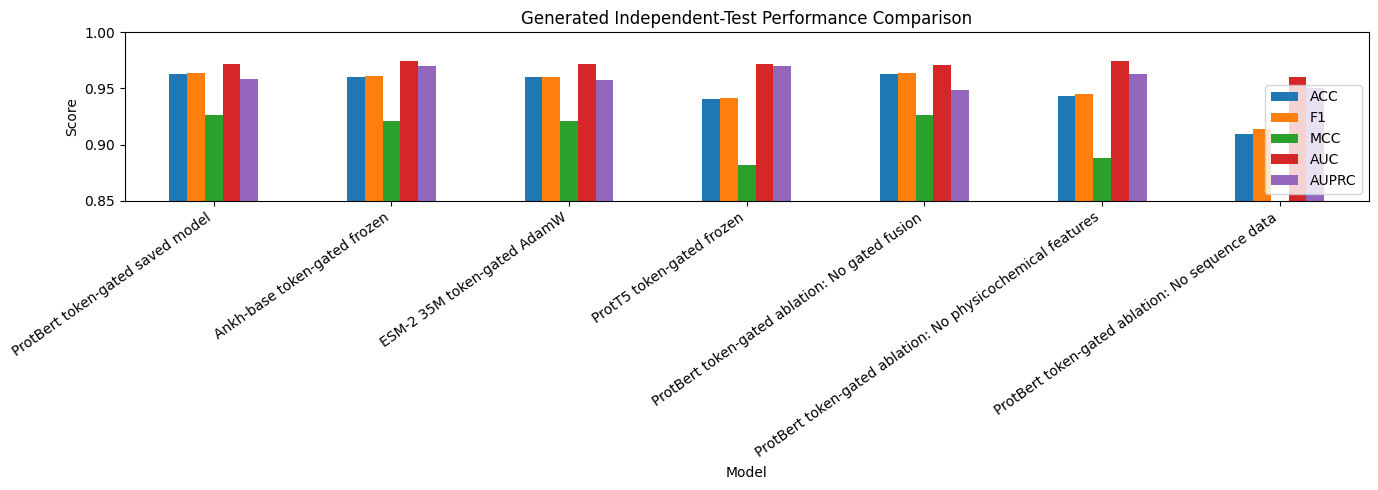

In [24]:
if results_df is None:
    print("pandas is required for this plot.")
elif results_df.empty:
    print("No generated experiment metrics available yet.")
else:
    import matplotlib.pyplot as plt

    plot_cols = [col for col in ["ACC", "F1", "MCC", "AUC", "AUPRC"] if col in results_df.columns]
    plot_df = results_df.set_index("Model")[plot_cols]

    ax = plot_df.plot(kind="bar", figsize=(14, 5), ylim=(0.85, 1.0))
    ax.set_title("Generated Independent-Test Performance Comparison")
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


## 16. Saved Outputs

Independent and ensemble runs save prediction CSV files under `outputs/` by default. Use this cell to inspect generated files after running experiments.


In [25]:
outputs_dir = PROJECT_DIR / "outputs"
if outputs_dir.exists():
    for path in sorted(outputs_dir.rglob("*")):
        if path.is_file():
            print(path.relative_to(PROJECT_DIR))
else:
    print("No outputs directory yet. Run an experiment first.")

outputs/ablation_no_gated_fusion/independent_test_predictions.csv
outputs/ablation_no_physicochemical/independent_test_predictions.csv
outputs/ablation_no_sequence/independent_test_predictions.csv
outputs/best_protbert_token_gated_sgd/feature_scaler_independent.joblib
outputs/best_protbert_token_gated_sgd/independent_test_predictions.csv
outputs/best_protbert_token_gated_sgd/token_gated_independent.pt
outputs/independent_test_predictions.csv
outputs/notebook_metrics/ankh_base_token_gated_frozen.json
outputs/notebook_metrics/esm_2_35m_token_gated_adamw.json
outputs/notebook_metrics/protbert_token_gated.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_gated_fusion.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_physicochemical_features.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_sequence_data.json
outputs/notebook_metrics/protbert_token_gated_saved_model.json
outputs/notebook_metrics/prott5_token_gated_frozen.json
outputs/paper_reported_met

## 17. Representation Visualization with t-SNE

This section provides a qualitative visualization of the learned feature space. The first plot uses the fused representation `z` from the trained ProtBert token-gated model, which is the representation passed into the residual classifier after sequence pooling, physicochemical projection, and gated fusion. The second plot uses the original 27 physicochemical features.

The goal is to visually inspect whether lactylated and non-lactylated sites become more separable after the proposed model learns its fused representation. t-SNE is only a visualization tool, so it should be interpreted alongside the quantitative metrics rather than as standalone proof.


### 17.1 Optional: Save the Best ProtBert Token-Gated Model

Run this cell only if the checkpoint does not already exist at `outputs/best_protbert_token_gated_sgd/token_gated_independent.pt`. The model must be saved before the fused representations can be extracted.


In [26]:
RUN_SAVE_BEST_PROTBERT_MODEL = False

save_best_protbert_cmd = runner_args(
    "--run", "independent",
    "--architecture", "token_gated",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
    "--optimizer", "sgd",
    "--learning-rate", "0.003",
    "--weight-decay", "0.0",
    "--scheduler", "none",
    "--save-models",
    "--output-dir", "outputs/best_protbert_token_gated_sgd",
)

run_experiment(
    label="ProtBert token-gated saved model",
    setting="SGD, 4 encoder layers, fine-tuned, saved checkpoint",
    command=save_best_protbert_cmd,
    run=RUN_SAVE_BEST_PROTBERT_MODEL,
    marker="Independent test:",
)


$ python scripts/run_replication.py --run independent --architecture token_gated --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --save-models --output-dir outputs/best_protbert_token_gated_sgd
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


### 17.2 Load the Saved Model and Independent Test Set

This cell restores the saved ProtBert token-gated model and the feature scaler used during training. It then prepares the independent test split for representation extraction.


In [27]:
from argparse import Namespace

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from pcbert_kla_clean.backbones import (
    infer_sequence_format,
    infer_site_token_index,
    load_tokenizer,
)
from pcbert_kla_clean.data import load_split
from pcbert_kla_clean.datasets import make_loader
from pcbert_kla_clean.training import build_model

BEST_MODEL_DIR = PROJECT_DIR / "outputs" / "best_protbert_token_gated_sgd"
MODEL_PATH = BEST_MODEL_DIR / "token_gated_independent.pt"
SCALER_PATH = BEST_MODEL_DIR / "feature_scaler_independent.joblib"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing saved model: {MODEL_PATH}. "
        "Run the optional save-model cell above first."
    )

if not SCALER_PATH.exists():
    raise FileNotFoundError(
        f"Missing saved scaler: {SCALER_PATH}. "
        "Run the optional save-model cell above first."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_root = PROJECT_DIR.parents[1] / "baselines" / "PCBert-Kla-original"

test_split = load_split(
    baseline_root / "data" / "test.csv",
    baseline_root / "data" / "feature_test.csv",
)

saved_scaler = joblib.load(SCALER_PATH)
scaled_test_features = saved_scaler.transform(test_split.features).astype(np.float32)

tsne_model_args = Namespace(
    architecture="token_gated",
    model_name="Rostlab/prot_bert",
    encoder_layers=4,
    fusion_dim=256,
    attention_dim=256,
    arch_dropout=0.2,
    site_token_index=infer_site_token_index("Rostlab/prot_bert"),
    freeze_encoder=False,
    cache_dir=None,
    ablation="none",
)

model = build_model(
    tsne_model_args,
    feature_dim=test_split.features.shape[1],
    device=device,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

tokenizer = load_tokenizer("Rostlab/prot_bert", cache_dir=None)
sequence_format = infer_sequence_format("Rostlab/prot_bert")

test_loader = make_loader(
    test_split,
    np.arange(len(test_split.labels)),
    scaled_test_features,
    tokenizer,
    batch_size=8,
    shuffle=False,
    max_length=64,
    sequence_format=sequence_format,
)

print("Loaded saved model:", MODEL_PATH.relative_to(PROJECT_DIR))
print("Loaded saved scaler:", SCALER_PATH.relative_to(PROJECT_DIR))
print("Independent test samples:", len(test_split.labels))


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded saved model: outputs/best_protbert_token_gated_sgd/token_gated_independent.pt
Loaded saved scaler: outputs/best_protbert_token_gated_sgd/feature_scaler_independent.joblib
Independent test samples: 354


### 17.3 Extract Fused Representations

The hook below captures the input to the residual classifier. For the full token-gated model, this tensor is the fused representation `z`, after gated fusion and before final classification.


In [28]:
fused_representations = []
true_labels = []


def capture_classifier_input(module, inputs):
    fused_representations.append(inputs[0].detach().cpu().numpy())


hook_handle = model.classifier.register_forward_pre_hook(capture_classifier_input)

with torch.no_grad():
    for batch in test_loader:
        encoded = {key: value.to(device) for key, value in batch["encoded"].items()}
        features = batch["features"].to(device)
        labels = batch["labels"].cpu().numpy()

        _ = model(features=features, **encoded)
        true_labels.extend(labels.tolist())

hook_handle.remove()

fused_representations = np.concatenate(fused_representations, axis=0)
true_labels = np.asarray(true_labels)

print("Fused representation shape:", fused_representations.shape)
print("Labels shape:", true_labels.shape)


Fused representation shape: (354, 256)
Labels shape: (354,)


### 17.4 Plot t-SNE Comparisons

The left plot shows the learned fused model representation. The right plot shows the original physicochemical feature space. Better class separation in the fused plot would visually support the value of the learned representation.


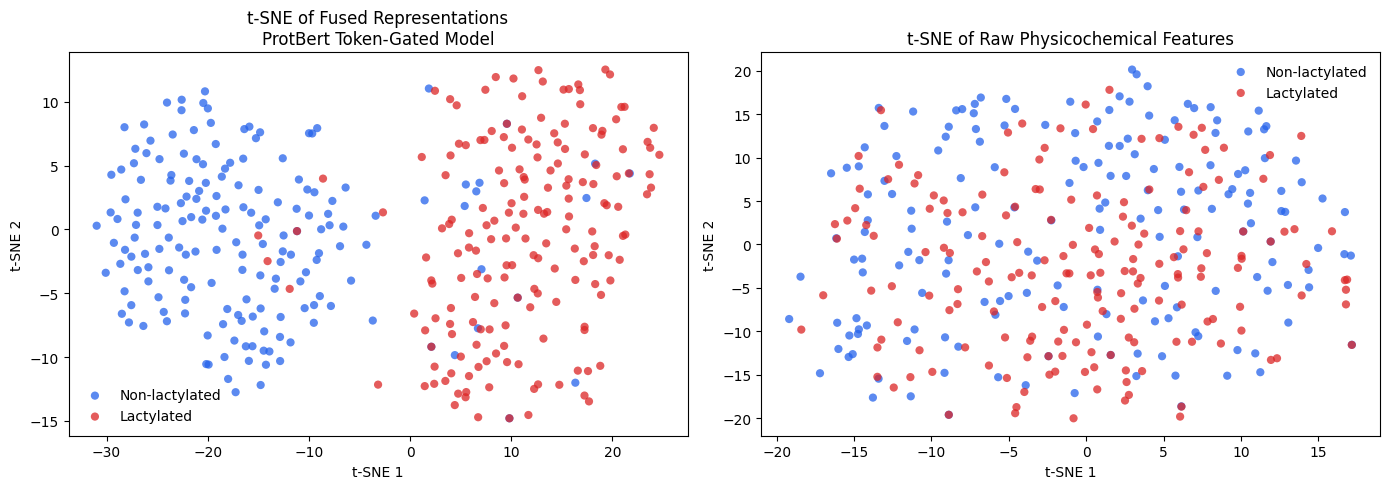

Saved t-SNE figure to: outputs/tsne_fused_vs_physicochemical.png


In [29]:
def run_tsne(features, random_state=42):
    standardized = StandardScaler().fit_transform(features)
    return TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
    ).fit_transform(standardized)


def plot_tsne(ax, embedding, labels, title):
    negative = labels == 0
    positive = labels == 1

    ax.scatter(
        embedding[negative, 0],
        embedding[negative, 1],
        s=35,
        alpha=0.75,
        label="Non-lactylated",
        c="#2563EB",
        edgecolors="none",
    )
    ax.scatter(
        embedding[positive, 0],
        embedding[positive, 1],
        s=35,
        alpha=0.75,
        label="Lactylated",
        c="#DC2626",
        edgecolors="none",
    )
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(frameon=False)


tsne_fused = run_tsne(fused_representations)
tsne_physicochemical = run_tsne(test_split.features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tsne(
    axes[0],
    tsne_fused,
    true_labels,
    "t-SNE of Fused Representations\nProtBert Token-Gated Model",
)
plot_tsne(
    axes[1],
    tsne_physicochemical,
    true_labels,
    "t-SNE of Raw Physicochemical Features",
)

plt.tight_layout()
figure_path = PROJECT_DIR / "outputs" / "tsne_fused_vs_physicochemical.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved t-SNE figure to:", figure_path.relative_to(PROJECT_DIR))


## 18. Additional Independent-Test Diagnostic Plots

These plots provide complementary evidence beyond the scalar metric table. The ROC and precision-recall curves show threshold-independent behavior from the saved independent-test probabilities. The confusion matrix summarizes the actual binary decisions at the selected threshold.


### 18.1 Load Saved Independent-Test Predictions

This cell reads the prediction CSV produced by the saved best ProtBert token-gated SGD model. Run section 17.1 first if this file does not exist.


In [30]:
from sklearn.metrics import (
    average_precision_score,
    auc,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

BEST_MODEL_DIR = PROJECT_DIR / "outputs" / "best_protbert_token_gated_sgd"
PREDICTIONS_PATH = BEST_MODEL_DIR / "independent_test_predictions.csv"

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing prediction file: {PREDICTIONS_PATH}. "
        "Run the save-best-model cell in section 17.1 first."
    )

prediction_df = pd.read_csv(PREDICTIONS_PATH)
required_columns = {"true_label", "score", "predicted_label"}
missing_columns = required_columns.difference(prediction_df.columns)
if missing_columns:
    raise ValueError(f"Prediction file is missing required columns: {sorted(missing_columns)}")

y_true = prediction_df["true_label"].astype(int).to_numpy()
y_score = prediction_df["score"].astype(float).to_numpy()
y_pred = prediction_df["predicted_label"].astype(int).to_numpy()

if "threshold" in prediction_df.columns:
    decision_threshold = float(prediction_df["threshold"].iloc[0])
else:
    decision_threshold = 0.5

print("Loaded predictions from:", PREDICTIONS_PATH.relative_to(PROJECT_DIR))
print("Samples:", len(prediction_df))
print("Decision threshold:", decision_threshold)
print("Positive labels:", int(y_true.sum()))
print("Negative labels:", int((1 - y_true).sum()))


Loaded predictions from: outputs/best_protbert_token_gated_sgd/independent_test_predictions.csv
Samples: 354
Decision threshold: 0.5
Positive labels: 177
Negative labels: 177


### 18.2 ROC and Precision-Recall Curves

The ROC curve visualizes sensitivity versus false-positive rate across thresholds. The precision-recall curve is especially useful for site-prediction tasks because it shows how precision changes as recall changes.


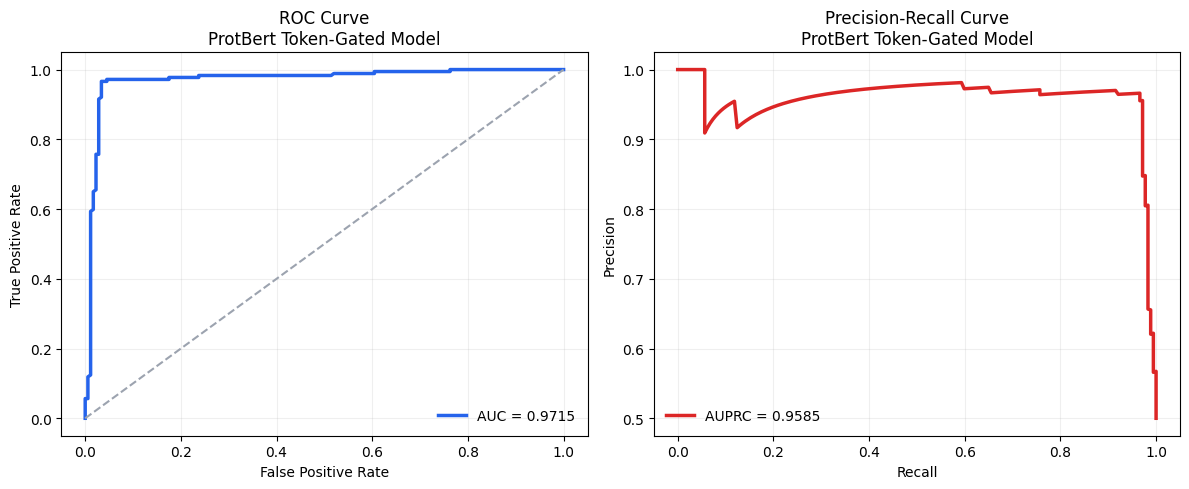

Saved ROC/PR figure to: outputs/roc_pr_curves.png


In [31]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_true, y_score)
average_precision = average_precision_score(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="#2563EB", linewidth=2.5, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="#9CA3AF", linestyle="--", linewidth=1.5)
axes[0].set_title("ROC Curve\nProtBert Token-Gated Model")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(frameon=False, loc="lower right")
axes[0].grid(alpha=0.2)

axes[1].plot(recall, precision, color="#DC2626", linewidth=2.5, label=f"AUPRC = {average_precision:.4f}")
axes[1].set_title("Precision-Recall Curve\nProtBert Token-Gated Model")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(frameon=False, loc="lower left")
axes[1].grid(alpha=0.2)

plt.tight_layout()
curve_path = PROJECT_DIR / "outputs" / "roc_pr_curves.png"
curve_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved ROC/PR figure to:", curve_path.relative_to(PROJECT_DIR))


### 18.3 Confusion Matrix

The confusion matrix shows the actual binary classification counts on the independent test set at the saved decision threshold.


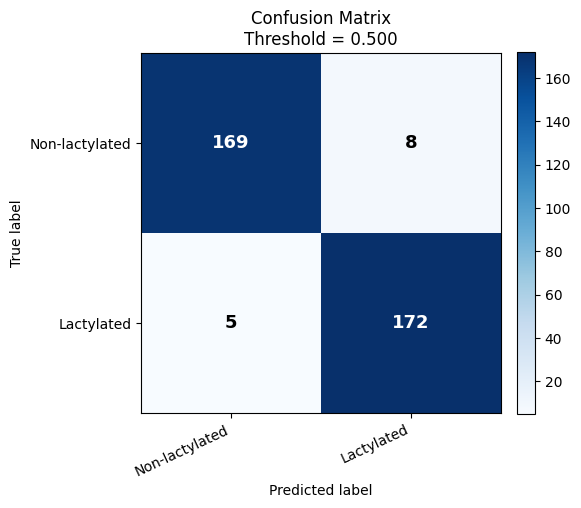

Saved confusion matrix to: outputs/confusion_matrix_best_model.png


In [32]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
class_names = ["Non-lactylated", "Lactylated"]

fig, ax = plt.subplots(figsize=(5.8, 5.2))
im = ax.imshow(cm, cmap="Blues")

ax.set_title(f"Confusion Matrix\nThreshold = {decision_threshold:.3f}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=25, ha="right")
ax.set_yticklabels(class_names)

threshold_for_text = cm.max() / 2.0
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(
            col,
            row,
            str(cm[row, col]),
            ha="center",
            va="center",
            color="white" if cm[row, col] > threshold_for_text else "black",
            fontsize=13,
            fontweight="bold",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = PROJECT_DIR / "outputs" / "confusion_matrix_best_model.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path.relative_to(PROJECT_DIR))


### 18.4 Ablation Metric Bar Plot

This plot compares the full ProtBert token-gated model against the three ablation scenarios. It is generated from notebook experiment records saved under `outputs/notebook_metrics/`, so run the full model and ablation cells before this plot.


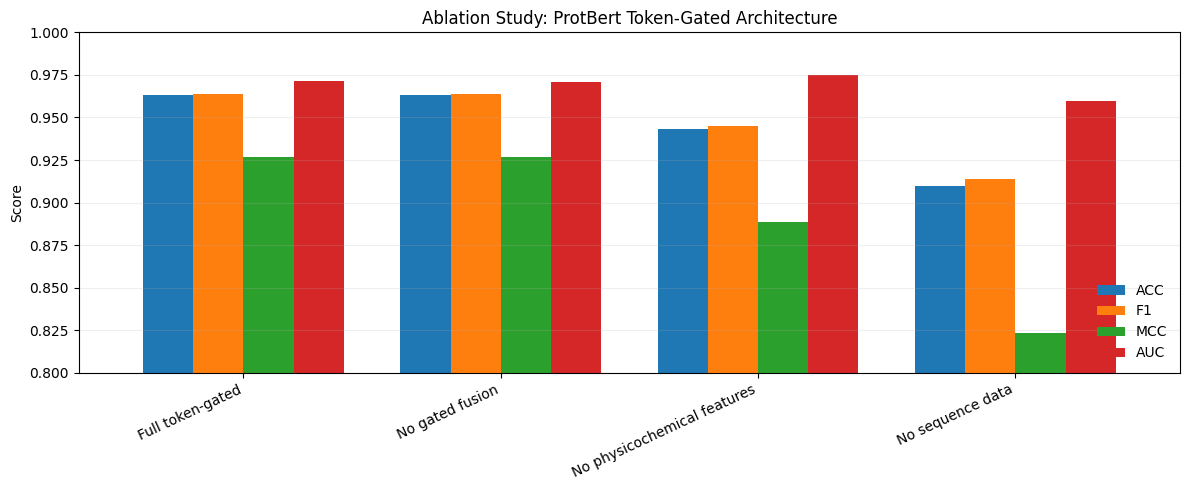

Saved ablation metric bar plot to: outputs/ablation_metric_bar_plot.png


,ACC,F1,MCC,AUC
Model,,,,
Full token-gated,0.963277,0.963585,0.926687,0.971544
No gated fusion,0.963277,0.963585,0.926687,0.970922
No physicochemical features,0.943503,0.945055,0.888425,0.974688
No sequence data,0.909605,0.913978,0.823478,0.959861


In [33]:
if pd is None:
    raise ModuleNotFoundError("pandas is required for the ablation plot.")

try:
    available_results = pd.DataFrame(experiment_records)
except NameError:
    available_results = pd.DataFrame()

if available_results.empty:
    available_results = load_saved_notebook_metrics()

if available_results.empty:
    raise RuntimeError("No generated metrics found. Run the full model and ablation cells first.")

model_names = available_results["Model"].astype(str)
full_mask = model_names.isin([
    "ProtBert token-gated",
    "ProtBert token-gated saved model",
])
ablation_mask = model_names.str.startswith("ProtBert token-gated ablation:")

full_rows = available_results.loc[full_mask].copy()
ablation_rows = available_results.loc[ablation_mask].copy()

if full_rows.empty:
    raise RuntimeError("Full ProtBert token-gated result not found. Run section 10 or section 17.1 first.")
if ablation_rows.empty:
    raise RuntimeError("Ablation results not found. Run section 12 ablation experiments first.")

full_row = full_rows.iloc[-1].copy()
full_row["Model"] = "Full token-gated"
ablation_rows["Model"] = ablation_rows["Model"].str.replace(
    "ProtBert token-gated ablation: ",
    "",
    regex=False,
)

plot_rows = pd.concat([pd.DataFrame([full_row]), ablation_rows], ignore_index=True)
plot_metrics = [metric for metric in ["ACC", "F1", "MCC", "AUC"] if metric in plot_rows.columns]
if not plot_metrics:
    raise RuntimeError("No supported metric columns found for ablation plotting.")

plot_data = plot_rows.set_index("Model")[plot_metrics].astype(float)

ax = plot_data.plot(kind="bar", figsize=(12, 5), ylim=(0.80, 1.0), width=0.78)
ax.set_title("Ablation Study: ProtBert Token-Gated Architecture")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

ablation_plot_path = PROJECT_DIR / "outputs" / "ablation_metric_bar_plot.png"
plt.savefig(ablation_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved ablation metric bar plot to:", ablation_plot_path.relative_to(PROJECT_DIR))
display(plot_data)


## 19. Biological Interpretation of Kla Prediction

This section connects the model results back to biological sequence context and physicochemical properties. The aim is not to claim a new biological mechanism from prediction alone, but to check whether the benchmark and the trained model show interpretable patterns around lysine lactylation sites.

The analyses below examine: residue enrichment around the central lysine, differences in the 27 physicochemical features, and the average model attention assigned to sequence positions near the central lysine.


### 19.1 Prepare Benchmark Samples for Biological Analysis

The independent test split is used by default so the interpretation is aligned with the evaluation results. The same code can be changed to use the training split if a larger motif summary is needed.


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pcbert_kla_clean.data import load_split

BIO_SPLIT_NAME = "independent_test"

baseline_root = PROJECT_DIR.parents[1] / "baselines" / "PCBert-Kla-original"

if BIO_SPLIT_NAME == "independent_test":
    bio_split = load_split(
        baseline_root / "data" / "test.csv",
        baseline_root / "data" / "feature_test.csv",
    )
elif BIO_SPLIT_NAME == "training":
    bio_split = load_split(
        baseline_root / "data" / "train.csv",
        baseline_root / "data" / "feature_train.csv",
    )
else:
    raise ValueError("BIO_SPLIT_NAME must be 'independent_test' or 'training'")

bio_sequences = np.asarray(bio_split.sequences)
bio_labels = bio_split.labels.astype(int)
bio_features = bio_split.features
bio_feature_names = bio_split.feature_names

positive_count = int(bio_labels.sum())
negative_count = int((1 - bio_labels).sum())
print("Biological analysis split:", BIO_SPLIT_NAME)
print("Samples:", len(bio_labels))
print("Lactylated:", positive_count)
print("Non-lactylated:", negative_count)
print("Feature dimension:", bio_features.shape[1])


Biological analysis split: independent_test
Samples: 354
Lactylated: 177
Non-lactylated: 177
Feature dimension: 27


### 19.2 Position-wise Amino Acid Enrichment Around Central Lysine

This heatmap compares amino acid frequencies in lactylated versus non-lactylated windows at each relative position. Positive values mean an amino acid is more frequent in lactylated sites; negative values mean it is more frequent in non-lactylated sites.


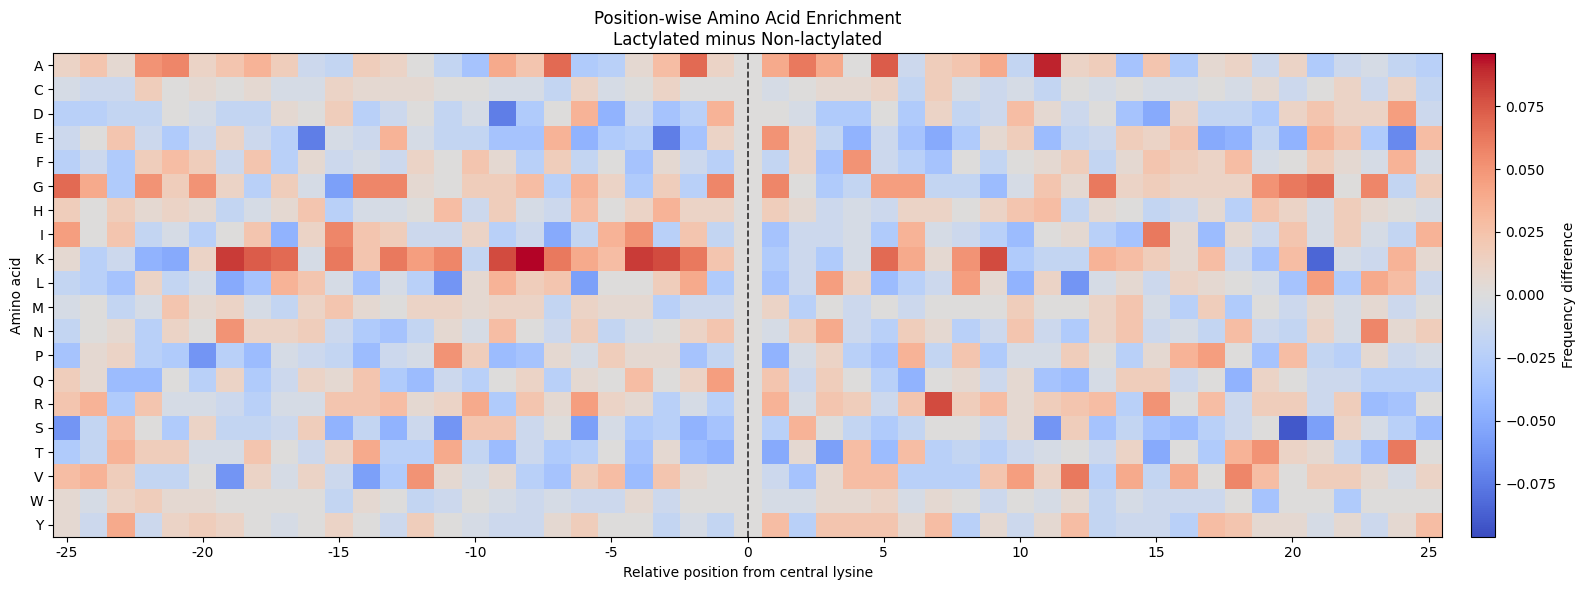

Saved enrichment heatmap to: outputs/amino_acid_enrichment_heatmap.png


In [35]:
amino_acids = sorted({residue for sequence in bio_sequences for residue in sequence})
window_length = len(bio_sequences[0])
center_index = window_length // 2
relative_positions = np.arange(window_length) - center_index

positive_sequences = bio_sequences[bio_labels == 1]
negative_sequences = bio_sequences[bio_labels == 0]


def residue_frequency_matrix(sequences, amino_acids):
    matrix = np.zeros((len(amino_acids), window_length), dtype=float)
    for position in range(window_length):
        residues_at_position = [sequence[position] for sequence in sequences]
        total = max(1, len(residues_at_position))
        counts = {residue: residues_at_position.count(residue) for residue in amino_acids}
        matrix[:, position] = [counts[residue] / total for residue in amino_acids]
    return matrix


positive_freq = residue_frequency_matrix(positive_sequences, amino_acids)
negative_freq = residue_frequency_matrix(negative_sequences, amino_acids)
enrichment = positive_freq - negative_freq

fig, ax = plt.subplots(figsize=(16, 6))
limit = max(abs(enrichment.min()), abs(enrichment.max()))
im = ax.imshow(enrichment, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)

ax.set_title("Position-wise Amino Acid Enrichment\nLactylated minus Non-lactylated")
ax.set_xlabel("Relative position from central lysine")
ax.set_ylabel("Amino acid")
ax.set_yticks(np.arange(len(amino_acids)))
ax.set_yticklabels(amino_acids)

x_tick_positions = np.arange(0, window_length, 5)
if center_index not in x_tick_positions:
    x_tick_positions = np.sort(np.append(x_tick_positions, center_index))
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(relative_positions[x_tick_positions])
ax.axvline(center_index, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Frequency difference")
plt.tight_layout()

enrichment_path = PROJECT_DIR / "outputs" / "amino_acid_enrichment_heatmap.png"
plt.savefig(enrichment_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved enrichment heatmap to:", enrichment_path.relative_to(PROJECT_DIR))


### 19.3 Physicochemical Feature Differences

This plot compares mean physicochemical feature values between lactylated and non-lactylated samples. Features with larger absolute differences may be useful biological descriptors of the local environment around candidate lysine sites.


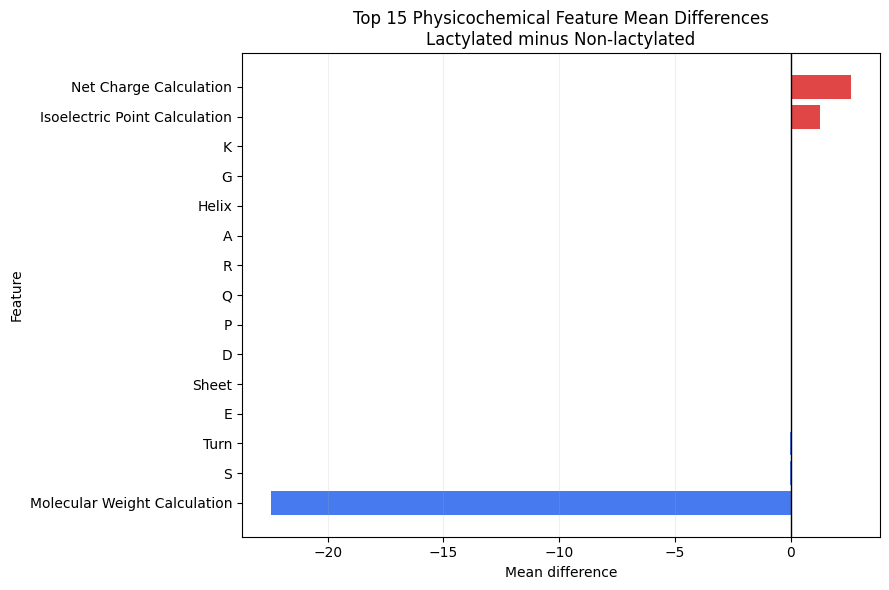

Saved physicochemical feature difference plot to: outputs/physicochemical_feature_differences.png


,feature,positive_mean,negative_mean,mean_difference
0,Molecular Weight Calculation,5674.204590,5696.657715,-22.453125
26,Net Charge Calculation,3.115689,0.518663,2.597026
1,Isoelectric Point Calculation,8.809712,7.552087,1.257625
10,K,0.111776,0.091503,0.020273
17,S,0.061150,0.078764,-0.017614
23,Turn,0.270189,0.286585,-0.016395
7,G,0.076991,0.061704,0.015287
22,Helix,0.361028,0.346294,0.014734
5,E,0.066910,0.080093,-0.013183
2,A,0.091503,0.078764,0.012740


In [36]:
positive_feature_mean = bio_features[bio_labels == 1].mean(axis=0)
negative_feature_mean = bio_features[bio_labels == 0].mean(axis=0)
feature_mean_difference = positive_feature_mean - negative_feature_mean

feature_diff_df = pd.DataFrame({
    "feature": bio_feature_names,
    "positive_mean": positive_feature_mean,
    "negative_mean": negative_feature_mean,
    "mean_difference": feature_mean_difference,
    "absolute_difference": np.abs(feature_mean_difference),
}).sort_values("absolute_difference", ascending=False)

top_n = min(15, len(feature_diff_df))
plot_df = feature_diff_df.head(top_n).sort_values("mean_difference")
colors = ["#2563EB" if value < 0 else "#DC2626" for value in plot_df["mean_difference"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["feature"], plot_df["mean_difference"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Top {top_n} Physicochemical Feature Mean Differences\nLactylated minus Non-lactylated")
ax.set_xlabel("Mean difference")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()

feature_diff_path = PROJECT_DIR / "outputs" / "physicochemical_feature_differences.png"
plt.savefig(feature_diff_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved physicochemical feature difference plot to:", feature_diff_path.relative_to(PROJECT_DIR))
display(feature_diff_df[["feature", "positive_mean", "negative_mean", "mean_difference"]].head(top_n))


### 19.4 Average Model Attention Around Central Lysine

The token-gated model uses central-lysine-guided token attention pooling before fusion. This plot averages the attention weights over independent-test samples, giving a model-specific view of which positions around the central lysine contribute most to the learned sequence representation.


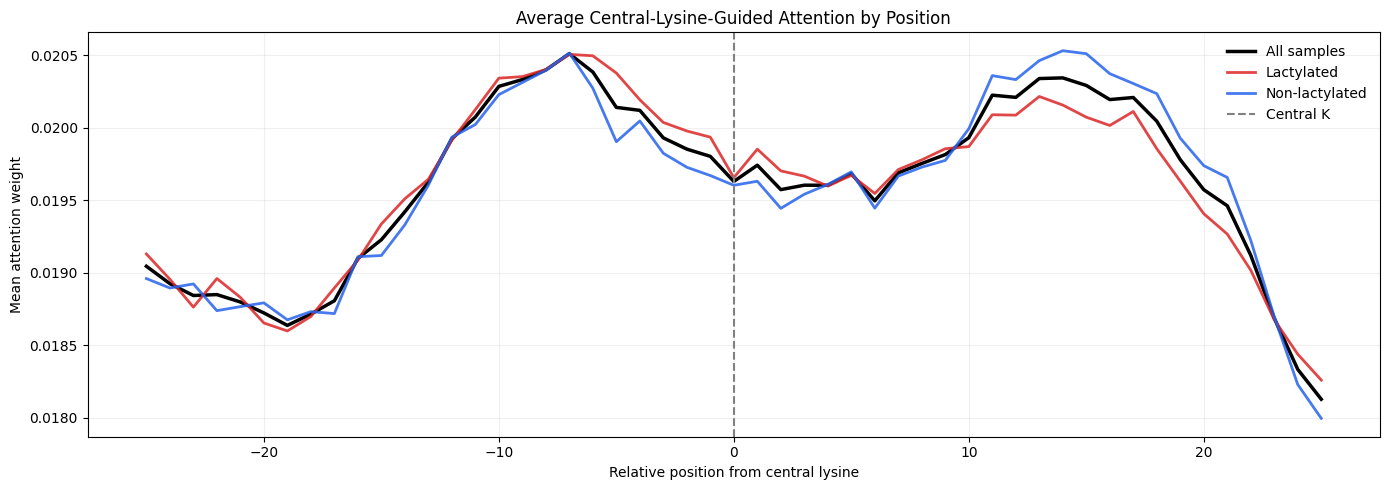

Saved attention plot to: outputs/average_site_attention_by_position.png


In [37]:
if "model" not in globals() or "test_loader" not in globals():
    raise RuntimeError(
        "The saved model and test_loader are not available. "
        "Run section 17.2 before computing attention interpretation."
    )

attention_rows = []
attention_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        encoded = {key: value.to(device) for key, value in batch["encoded"].items()}
        features = batch["features"].to(device)
        labels = batch["labels"].cpu().numpy()

        model_inputs = {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
        }
        if "token_type_ids" in encoded:
            model_inputs["token_type_ids"] = encoded["token_type_ids"]

        outputs = model.encoder(**model_inputs)
        token_embeddings = outputs.last_hidden_state.to(features.dtype)
        site_attention = model.site_attention
        sequence_length = token_embeddings.shape[1]
        site_index = min(site_attention.site_token_index, sequence_length - 1)
        site_embedding = token_embeddings[:, site_index, :]

        logits = site_attention.score(
            torch.tanh(
                site_attention.token_projection(token_embeddings)
                + site_attention.site_projection(site_embedding).unsqueeze(1)
            )
        ).squeeze(-1)

        residue_mask = encoded["attention_mask"].bool().clone()
        if site_attention.has_start_token:
            residue_mask[:, 0] = False
        sep_indices = encoded["attention_mask"].long().sum(dim=1) - 1
        residue_mask[
            torch.arange(residue_mask.shape[0], device=residue_mask.device),
            sep_indices,
        ] = False

        logits = logits.masked_fill(~residue_mask, torch.finfo(logits.dtype).min)
        weights = torch.softmax(logits, dim=1).detach().cpu().numpy()

        for row_weights in weights:
            if site_attention.has_start_token:
                residue_weights = row_weights[1:52]
            else:
                residue_weights = row_weights[:51]
            attention_rows.append(residue_weights)
        attention_labels.extend(labels.tolist())

attention_matrix = np.vstack(attention_rows)
attention_labels = np.asarray(attention_labels).astype(int)
attention_positions = np.arange(attention_matrix.shape[1]) - (attention_matrix.shape[1] // 2)

mean_attention_all = attention_matrix.mean(axis=0)
mean_attention_positive = attention_matrix[attention_labels == 1].mean(axis=0)
mean_attention_negative = attention_matrix[attention_labels == 0].mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(attention_positions, mean_attention_all, color="black", linewidth=2.5, label="All samples")
ax.plot(attention_positions, mean_attention_positive, color="#DC2626", linewidth=2, alpha=0.85, label="Lactylated")
ax.plot(attention_positions, mean_attention_negative, color="#2563EB", linewidth=2, alpha=0.85, label="Non-lactylated")
ax.axvline(0, color="gray", linestyle="--", linewidth=1.5, label="Central K")
ax.set_title("Average Central-Lysine-Guided Attention by Position")
ax.set_xlabel("Relative position from central lysine")
ax.set_ylabel("Mean attention weight")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()

attention_path = PROJECT_DIR / "outputs" / "average_site_attention_by_position.png"
plt.savefig(attention_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved attention plot to:", attention_path.relative_to(PROJECT_DIR))


### 19.5 Biological Interpretation Summary

The observed differences in net charge, isoelectric point, molecular weight, and residue-composition descriptors indicate that lactylated and non-lactylated lysine-centered peptides occupy distinguishable physicochemical environments. In particular, charge-related descriptors are biologically relevant because lysine is a positively charged residue and lactylation modifies its side chain. These findings support the inclusion of physicochemical features as complementary information to protein language model embeddings.
